# Transfer Success Evaluation

Rule-based framework anchored to destination-adjusted player projections (`player_projections.value_per_100`). No separate ML model — success is defined as meeting or exceeding the projection baseline.

| Step | What it does |
|---|---|
| **1. Data Load** | Joins `transfers` → `player_projections` → `player_archetypes` → `team_system_profiles` → `hoop_explorer_player_stats` |
| **2. Success Label** | `actual_value_per_100 >= projected_value_per_100` (primary); `post_per >= pre_per` fallback |
| **3. Drift Metrics** | `minutes_drift`, `usage_drift` = actual minus projected |
| **4. Player Clusters** | Pulled directly from `player_archetypes` |
| **5. Team Clusters** | Pulled directly from `team_system_profiles.cluster_id` + `system_label`|
| **6. Success Probability** | Empirical Bayes shrinkage over **Player Cluster × Team Cluster** cells (both from the DB) |
| **7. Risk Explanations** | Rule-based mapping from drift + success probability → human-readable UI strings |


In [75]:
# Cell 0 — Imports + Config
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

# --- Config ---
CURRENT_SEASON = 2025   # season we're projecting into
SHRINKAGE_K    = 10     # Empirical Bayes shrinkage constant (K pseudo-observations from cluster prior)
CELL_MIN_N     = 15     # n below which shrinkage is meaningfully active

# Set True to skip DB and use generated data for exploration
USE_SYNTHETIC = False

## 1. Data Loading

Single SQL query joins five tables. Key join: `team_system_profiles` on `(to_school_id, season)` supplies the **DB-native program cluster** — no downstream KMeans needed.

| Source column | Maps to | Notes |
|---|---|---|
| `team_system_profiles.cluster_id` | `team_cluster_id` | Integer cluster ID from Model 2 |
| `team_system_profiles.system_label` | `team_cluster_label` | Combined offense+defense style string |
| `team_system_profiles.offense_cluster_id` | `team_offense_cluster_id` | Optional sub-dimension |
| `team_system_profiles.defense_cluster_id` | `team_defense_cluster_id` | Optional sub-dimension |
| `player_archetypes.archetype_id` | `player_cluster` | 0–10, season before the transfer |
| `hoop_explorer_player_stats.adj_rapm_prod_margin` | `actual_value_per_100` | Production-weighted RAPM — same lineage as `value_per_100` |

In [76]:
# Cell 1 — DB connect + load all transfer evaluation data
TRANSFER_SQL = """
SELECT
    t.id                              AS transfer_id,
    t.player_id,
    p.full_name                       AS player_name,
    t.from_school_id,
    t.to_school_id,
    t.season,
    t.transfer_type,
    -- Pre-transfer snapshot
    t.pre_per,
    t.pre_minutes_per_game,
    t.pre_usage_rate,
    -- Post-transfer actuals
    t.post_per,
    t.post_minutes_per_game,
    t.post_usage_rate,
    t.per_change,
    t.minutes_change,
    -- Destination-adjusted projection (our 50th-pct value baseline)
    pp.value_per_100                  AS projected_value_per_100,
    pp.projected_minutes,
    pp.projected_usage,
    pp.value_ci_lower,
    pp.value_ci_upper,
    -- Player archetype for the pre-transfer season
    pa.archetype_id                   AS player_cluster,
    pa.archetype_label                AS player_cluster_label,
    -- DB-native program cluster from team_system_profiles (Model 2 output)
    -- Unique per (school_id, season) — no fan-out risk
    tsp.cluster_id                    AS team_cluster_id,
    tsp.system_label                  AS team_cluster_label,
    tsp.offense_cluster_id            AS team_offense_cluster_id,
    tsp.defense_cluster_id            AS team_defense_cluster_id,
    -- HoopExplorer actual RAPM for the post-transfer season
    -- adj_rapm_prod_margin = production-weighted RAPM (same lineage as value_per_100)
    he.adj_rapm_prod_margin           AS actual_value_per_100
FROM transfers t
JOIN players p
    ON  p.id = t.player_id
-- Destination-adjusted projection for this player × school × season
LEFT JOIN player_projections pp
    ON  pp.player_id       = t.player_id
    AND pp.school_id       = t.to_school_id
    AND pp.season          = t.season
    AND pp.projection_mode = 'destination'
-- Player archetype label for the season before the transfer
LEFT JOIN player_archetypes pa
    ON  pa.player_id = t.player_id
    AND pa.season    = (t.season - 1)
-- DB-native program cluster for the destination team in this specific season
LEFT JOIN team_system_profiles tsp
    ON  tsp.school_id = t.to_school_id
    AND tsp.season    = t.season
-- HoopExplorer actual performance for the post-transfer season
LEFT JOIN hoop_explorer_player_stats he
    ON  he.player_id = t.player_id
    AND he.season    = t.season
WHERE t.post_minutes_per_game IS NOT NULL   -- completed transfers only
ORDER BY t.season, t.player_id
"""

try:
    from portalpoint.modeling.io import get_sync_engine
    engine = get_sync_engine()
    conn   = engine.raw_connection()

    df_transfers = pd.read_sql(TRANSFER_SQL, conn)
    conn.close()

    print(f"Loaded {len(df_transfers):,} completed transfers across {df_transfers['season'].nunique()} seasons")
    print(f"  Rows with team_cluster_id:  {df_transfers['team_cluster_id'].notna().sum():,}")
    print(f"  Rows with player_cluster:   {df_transfers['player_cluster'].notna().sum():,}")
    print(f"  Rows with actual RAPM:      {df_transfers['actual_value_per_100'].notna().sum():,}")
    print(f"  Rows with projection:       {df_transfers['projected_value_per_100'].notna().sum():,}")

    if len(df_transfers) == 0:
        print("No completed transfers found — switching to synthetic data")
        USE_SYNTHETIC = True

except Exception as e:
    print(f"DB connection failed: {e}")
    print("Falling back to synthetic data for exploration.")
    USE_SYNTHETIC = True

DB connection failed: No module named 'portalpoint'
Falling back to synthetic data for exploration.


## 1b. Synthetic Data (Exploration Mode)

Generates realistic-looking transfer data when the DB is unavailable. Skipped when `USE_SYNTHETIC = False`.

Mirrors the DB schema:
- **`player_cluster`** (0–10): 11 archetypes from `player_archetypes`
- **`team_cluster_id`** (0–7): 8 program style clusters as would appear in `team_system_profiles`
- **`team_cluster_label`**: combined offense+defense style strings matching the `system_label` column format

In [77]:
# Cell 2 — Synthetic data generator (skipped when USE_SYNTHETIC=False)
if USE_SYNTHETIC:
    rng = np.random.default_rng(42)
    N   = 500

    # Mirrors player_archetypes.archetype_label values (11 clusters)
    PLAYER_ARCHETYPE_LABELS = [
        "Elite Scorer", "3&D Wing", "Rim Protector", "Playmaker",
        "Stretch Big", "Combo Guard", "Slasher", "Post Scorer",
        "Defensive Stopper", "Utility Forward", "Spot-Up Shooter",
    ]

    # Mirrors team_system_profiles.system_label format (8 clusters)
    TEAM_SYSTEM_LABELS = [
        "High-Tempo Rim Attack / Aggressive Press",
        "Motion Offense / Pack-Line Man Defense",
        "3-PT Heavy Spread / Drop Coverage",
        "Slow Tempo Post Up / Switching Man",
        "Transition Heavy / Zone Heavy",
        "Princeton Style / Help & Recover",
        "Pick-and-Roll Primary / Hedge & Recover",
        "Spread Floor Isolate / Scramble Defense",
    ]

    player_clusters  = rng.integers(0, 11, size=N)
    team_clusters    = rng.integers(0, 8,  size=N)
    seasons          = rng.choice([2022, 2023, 2024, 2025], size=N)
    projected_value  = rng.normal(0.0, 3.0, size=N)
    actual_value     = projected_value + rng.normal(0.0, 2.0, size=N)

    projected_min    = rng.uniform(15, 30, size=N)
    projected_usage  = rng.uniform(14, 28, size=N)
    post_min         = (projected_min   + rng.normal(0, 5, size=N)).clip(0)
    post_usage       = (projected_usage + rng.normal(0, 4, size=N)).clip(0)
    pre_per          = rng.uniform(8, 22, size=N)
    post_per         = pre_per + rng.normal(0, 3, size=N)

    df_transfers = pd.DataFrame({
        "transfer_id":               np.arange(N),
        "player_id":                 rng.integers(1000, 9999, size=N),
        "player_name":               [f"Player_{i}" for i in range(N)],
        "from_school_id":            rng.integers(1, 200, size=N),
        "to_school_id":              rng.integers(1, 200, size=N),
        "season":                    seasons,
        "transfer_type":             rng.choice(["graduate", "regular"], size=N),
        "pre_per":                   pre_per,
        "pre_minutes_per_game":      rng.uniform(10, 30, size=N),
        "pre_usage_rate":            rng.uniform(12, 30, size=N),
        "post_per":                  post_per,
        "post_minutes_per_game":     post_min,
        "post_usage_rate":           post_usage,
        "per_change":                post_per - pre_per,
        "minutes_change":            post_min - projected_min,
        "projected_value_per_100":   projected_value,
        "projected_minutes":         projected_min,
        "projected_usage":           projected_usage,
        "value_ci_lower":            projected_value - 2.0,
        "value_ci_upper":            projected_value + 2.0,
        "player_cluster":            player_clusters,
        "player_cluster_label":      [PLAYER_ARCHETYPE_LABELS[c] for c in player_clusters],
        # DB-native team system profile columns (mirrors team_system_profiles)
        "team_cluster_id":           team_clusters,
        "team_cluster_label":        [TEAM_SYSTEM_LABELS[c] for c in team_clusters],
        "team_offense_cluster_id":   rng.integers(0, 4, size=N),
        "team_defense_cluster_id":   rng.integers(0, 4, size=N),
        "actual_value_per_100":      actual_value,
    })

    print(f"Synthetic data: {len(df_transfers):,} transfers")
    print(f"Player clusters: {sorted(df_transfers['player_cluster'].unique())}")
    print(f"Team clusters:   {sorted(df_transfers['team_cluster_id'].unique())}")
    display(df_transfers.iloc[:2].T)

Synthetic data: 500 transfers
Player clusters: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Team clusters:   [0, 1, 2, 3, 4, 5, 6, 7]


,0,1
transfer_id,0,1
player_id,7568,6351
player_name,Player_0,Player_1
from_school_id,140,110
to_school_id,117,59
season,2025,2024
transfer_type,regular,graduate
pre_per,12.886,17.774
pre_minutes_per_game,26.607,11.251
pre_usage_rate,27.275,18.289


## 2. Success Label & Drift Metrics

**Success Label** — a Boolean flag:
- **Primary**: `actual_value_per_100 >= projected_value_per_100`
  - `actual_value_per_100` = `hoop_explorer_player_stats.adj_rapm_prod_margin` (same family as the projection's `value_per_100`)
- **Fallback**: `post_per >= pre_per` when no HoopExplorer row exists for this player-season

**Drift Metrics** — raw signed deviations:
- `minutes_drift` = `post_minutes_per_game − projected_minutes`
- `usage_drift`   = `post_usage_rate − projected_usage`

Negative = player got less than projected; positive = exceeded projection.

In [78]:
# Cell 3 — Success label + drift

def label_transfer_success(df: pd.DataFrame) -> pd.DataFrame:
    """Assign success_label (bool) to each completed transfer.

    Primary: actual_value_per_100 >= projected_value_per_100 (both non-null).
    Fallback: post_per >= pre_per when projection or HE RAPM data is missing.
    Rows with neither comparison possible get success = NaN.
    """
    df = df.copy()

    has_rapm = df["actual_value_per_100"].notna() & df["projected_value_per_100"].notna()
    has_per  = df["post_per"].notna() & df["pre_per"].notna()

    df["success"] = np.nan

    # Primary: RAPM vs destination projection
    df.loc[has_rapm, "success"] = (
        df.loc[has_rapm, "actual_value_per_100"] >= df.loc[has_rapm, "projected_value_per_100"]
    ).astype(float)

    # Fallback: PER improvement when projection / HE data is unavailable
    fallback = ~has_rapm & has_per
    df.loc[fallback, "success"] = (
        df.loc[fallback, "post_per"] >= df.loc[fallback, "pre_per"]
    ).astype(float)

    df["success_label"]       = df["success"].map({1.0: True, 0.0: False})
    df["value_vs_projection"] = df["actual_value_per_100"] - df["projected_value_per_100"]
    df["label_source"] = np.where(
        has_rapm, "rapm_vs_projection",
        np.where(fallback, "per_improvement", "missing"),
    )

    return df


def compute_drift(df: pd.DataFrame) -> pd.DataFrame:
    """Volume and efficiency drift: actual minus projected."""
    df = df.copy()
    df["minutes_drift"] = df["post_minutes_per_game"] - df["projected_minutes"]
    df["usage_drift"]   = df["post_usage_rate"]        - df["projected_usage"]
    return df


df = label_transfer_success(df_transfers)
df = compute_drift(df)

print("Label source breakdown:")
print(df["label_source"].value_counts().to_string())
print(f"\nOverall success rate: {df['success'].mean():.1%}  (n={df['success'].notna().sum():,} labeled)")
print(f"Unlabeled (missing data): {df['success'].isna().sum():,}")

Label source breakdown:
rapm_vs_projection    500

Overall success rate: 49.0%  (n=500 labeled)
Unlabeled (missing data): 0


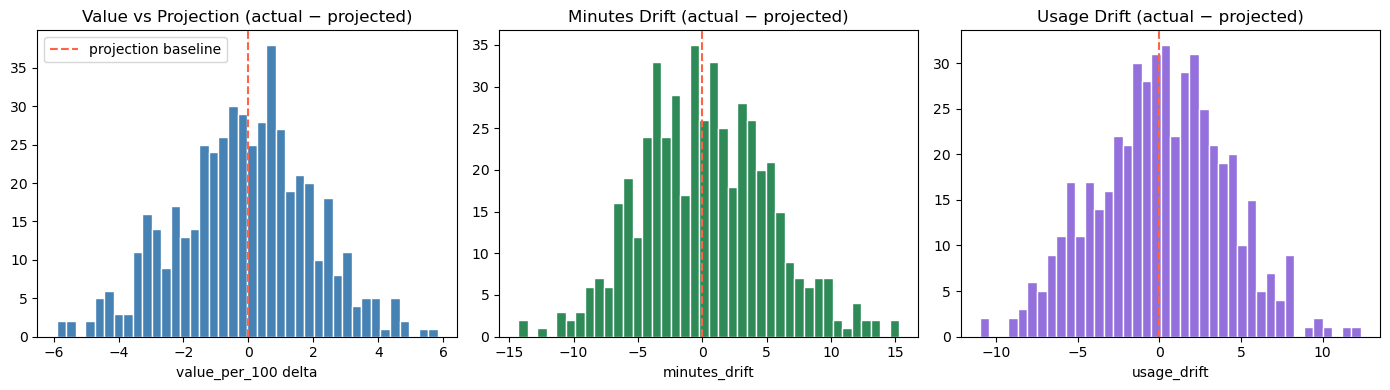


Drift summary stats:


,value_vs_projection,minutes_drift,usage_drift
count,500.000,500.000,500.000
mean,-0.118,0.210,0.126
std,2.075,4.978,3.941
min,-5.911,-14.308,-10.998
25%,-1.412,-3.327,-2.516
50%,-0.045,0.050,0.196
75%,1.217,3.710,2.846
max,5.828,15.298,12.354


In [79]:
# Cell 4 — Drift distribution diagnostics
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df["value_vs_projection"].dropna(), bins=40, edgecolor="white", color="steelblue")
axes[0].axvline(0, color="tomato", linewidth=1.5, linestyle="--", label="projection baseline")
axes[0].set_title("Value vs Projection (actual − projected)")
axes[0].set_xlabel("value_per_100 delta")
axes[0].legend()

axes[1].hist(df["minutes_drift"].dropna(), bins=40, edgecolor="white", color="seagreen")
axes[1].axvline(0, color="tomato", linewidth=1.5, linestyle="--")
axes[1].set_title("Minutes Drift (actual − projected)")
axes[1].set_xlabel("minutes_drift")

axes[2].hist(df["usage_drift"].dropna(), bins=40, edgecolor="white", color="mediumpurple")
axes[2].axvline(0, color="tomato", linewidth=1.5, linestyle="--")
axes[2].set_title("Usage Drift (actual − projected)")
axes[2].set_xlabel("usage_drift")

plt.tight_layout()
plt.show()

print("\nDrift summary stats:")
display(df[["value_vs_projection", "minutes_drift", "usage_drift"]].describe().round(3))

## 3. Team Cluster Inspection

The program cluster dimension comes directly from `team_system_profiles.cluster_id` / `system_label` — no re-clustering. This is the Model 2 output already persisted in the DB.

This cell provides a quick EDA of how historical transfers are distributed across team clusters and what the raw (un-shrunk) success rate looks like per cluster.

In [80]:
# Cell 5 — Team cluster coverage EDA
unmatched = df["team_cluster_id"].isna().sum()
print(f"Transfers without a team_system_profiles row: {unmatched:,} ({unmatched/len(df):.1%})")
print("These will receive confidence = global cluster prior (W=0 shrinkage).\n")

team_cluster_summary = (
    df[df["team_cluster_id"].notna()]
    .groupby(["team_cluster_id", "team_cluster_label"], dropna=False)
    .agg(
        n_transfers=("transfer_id", "count"),
        raw_success_rate=("success", "mean"),
        mean_minutes_drift=("minutes_drift", "mean"),
        mean_usage_drift=("usage_drift", "mean"),
    )
    .reset_index()
    .sort_values("team_cluster_id")
)

print("Transfers per DB team cluster (team_system_profiles.cluster_id):")
display(team_cluster_summary.round(3))

# Also show cross-tab of player clusters vs team clusters
print("\nPlayer cluster × Team cluster transfer counts:")
crosstab = (
    df[df["team_cluster_id"].notna() & df["player_cluster"].notna()]
    .groupby(["player_cluster", "team_cluster_id"])
    .size()
    .unstack(fill_value=0)
)
crosstab.columns = [f"team_{c}" for c in crosstab.columns]
display(crosstab)

Transfers without a team_system_profiles row: 0 (0.0%)
These will receive confidence = global cluster prior (W=0 shrinkage).

Transfers per DB team cluster (team_system_profiles.cluster_id):


,team_cluster_id,team_cluster_label,n_transfers,raw_success_rate,mean_minutes_drift,mean_usage_drift
0,0,High-Tempo Rim Attack / Aggressive Press,66,0.530,1.075,1.307
1,1,Motion Offense / Pack-Line Man Defense,65,0.508,-0.387,0.530
2,2,3-PT Heavy Spread / Drop Coverage,46,0.565,0.376,0.312
3,3,Slow Tempo Post Up / Switching Man,58,0.414,0.412,0.201
4,4,Transition Heavy / Zone Heavy,73,0.562,0.035,-0.683
5,5,Princeton Style / Help & Recover,64,0.500,-0.658,0.146
6,6,Pick-and-Roll Primary / Hedge & Recover,65,0.369,0.402,0.264
7,7,Spread Floor Isolate / Scramble Defense,63,0.476,0.502,-0.957



Player cluster × Team cluster transfer counts:


,team_0,team_1,team_2,team_3,team_4,team_5,team_6,team_7
player_cluster,,,,,,,,
0,4,5,5,7,9,1,5,4
1,6,8,2,7,7,11,9,8
2,8,4,1,5,5,4,3,2
3,5,4,4,6,7,6,8,8
4,4,8,4,9,11,1,7,5
5,4,6,6,7,4,8,2,11
6,4,8,5,5,2,7,7,5
7,7,6,3,2,9,6,6,6
8,10,5,7,4,3,10,10,4


## 4. Empirical Bayes Success Probability

We compute a historical success rate for each **`(player_cluster, team_cluster_id)`** cell — where both dimensions come directly from the DB — then shrink thin cells toward the global rate for that player cluster.

**Shrinkage formula**:

$$W = \frac{n}{n + K}$$

$$\text{probability} = W \cdot \text{cell\_rate} + (1 - W) \cdot \text{cluster\_rate}$$

- $n$ = completed transfers in the `(player_cluster, team_cluster_id)` cell  
- $K = 10$ — adding 10 pseudo-observations from the cluster-level prior  
- **When $n \gg K$**: probability ≈ cell rate (cell has enough historical signal)  
- **When $n < 15$**: shrinkage is active, probability pulls toward the safer cluster prior  
- **When `team_cluster_id` is NULL** (no `team_system_profiles` row): $W = 0$, probability = cluster prior

The three-level hierarchy is:
```
player_cluster × team_cluster_id  (cell, n >= 15: trust cell rate)
    ↓ shrink if n < 15
player_cluster global rate        (cluster prior)
    ↓ if player_cluster also missing
global average                    (overall population prior)
```

In [81]:
# Cell 6 — Empirical Bayes probability scoring

def compute_success_probabilitys(
    df: pd.DataFrame,
    shrinkage_k: int = SHRINKAGE_K,
) -> pd.DataFrame:
    """Hierarchical shrinkage probability over (player_cluster × team_cluster_id) cells.

    Three-level fallback:
      1. Cell rate (player_cluster × team_cluster_id) — shrunk toward level 2 when n < K
      2. Global player cluster rate — used as the prior for shrinkage and for NULL team_cluster_id
      3. Overall population rate — used when player_cluster itself is NULL

    W = n / (n + K)  where K is the shrinkage constant.
    probability = W * cell_rate + (1 - W) * cluster_rate
    """
    df = df.copy()
    labeled = df[df["success"].notna()]

    # Level 3: global population prior (fallback for missing player_cluster)
    global_rate = labeled["success"].mean()

    # Level 2: success rate per player_cluster (the Bayesian prior)
    cluster_global = (
        labeled
        .groupby("player_cluster", dropna=False)["success"]
        .agg(cluster_success_rate="mean", cluster_n="count")
        .reset_index()
    )

    # Level 1: cell-level rate — player_cluster × team_cluster_id (DB-native dimensions)
    cell_stats = (
        labeled[labeled["team_cluster_id"].notna()]
        .groupby(["player_cluster", "team_cluster_id"], dropna=False)["success"]
        .agg(cell_success_rate="mean", cell_n="count")
        .reset_index()
    )

    df = df.merge(
        cluster_global[["player_cluster", "cluster_success_rate"]],
        on="player_cluster", how="left",
    )
    df = df.merge(cell_stats, on=["player_cluster", "team_cluster_id"], how="left")

    # Fill missing cluster rate with global population rate
    df["cluster_success_rate"] = df["cluster_success_rate"].fillna(global_rate)

    # Rows with no team_cluster_id: cell_n = 0 → W = 0 → probability = cluster prior
    df["cell_n"]            = df["cell_n"].fillna(0).astype(int)
    df["cell_success_rate"] = df["cell_success_rate"].fillna(df["cluster_success_rate"])

    # Shrinkage weight: W → 0 when n is small (shrink to prior); W → 1 when n is large
    df["shrinkage_w"]     = df["cell_n"] / (df["cell_n"] + shrinkage_k)
    df["success_probability"] = (
        df["shrinkage_w"] * df["cell_success_rate"]
        + (1 - df["shrinkage_w"]) * df["cluster_success_rate"]
    )

    df["success_tier"] = pd.cut(
        df["success_probability"],
        bins=[0.0, 0.35, 0.50, 0.65, 0.80, 1.01],
        labels=["Very Low", "Low", "Moderate", "High", "Very High"],
        include_lowest=True,
    )

    return df


df = compute_success_probabilitys(df)

print("Shrinkage weight distribution (W = n / (n + 10)):")
display(
    df[["cell_n", "shrinkage_w", "cluster_success_rate", "cell_success_rate", "success_probability"]]
    .describe().round(3)
)
print("\nTransfers per confidence tier:")
display(df["success_tier"].value_counts().sort_index())

Shrinkage weight distribution (W = n / (n + 10)):


,cell_n,shrinkage_w,cluster_success_rate,cell_success_rate,success_probability
count,500.000,500.000,500.000,500.000,500.000
mean,6.740,0.391,0.490,0.490,0.488
std,2.291,0.087,0.089,0.217,0.110
min,1.000,0.091,0.306,0.000,0.219
25%,5.000,0.333,0.425,0.333,0.418
50%,7.000,0.412,0.500,0.500,0.483
75%,8.000,0.444,0.568,0.606,0.562
max,11.000,0.524,0.623,1.000,0.748



Transfers per confidence tier:


Very Low      51
Low          243
Moderate     175
High          31
Very High      0
Name: success_tier, dtype: int64

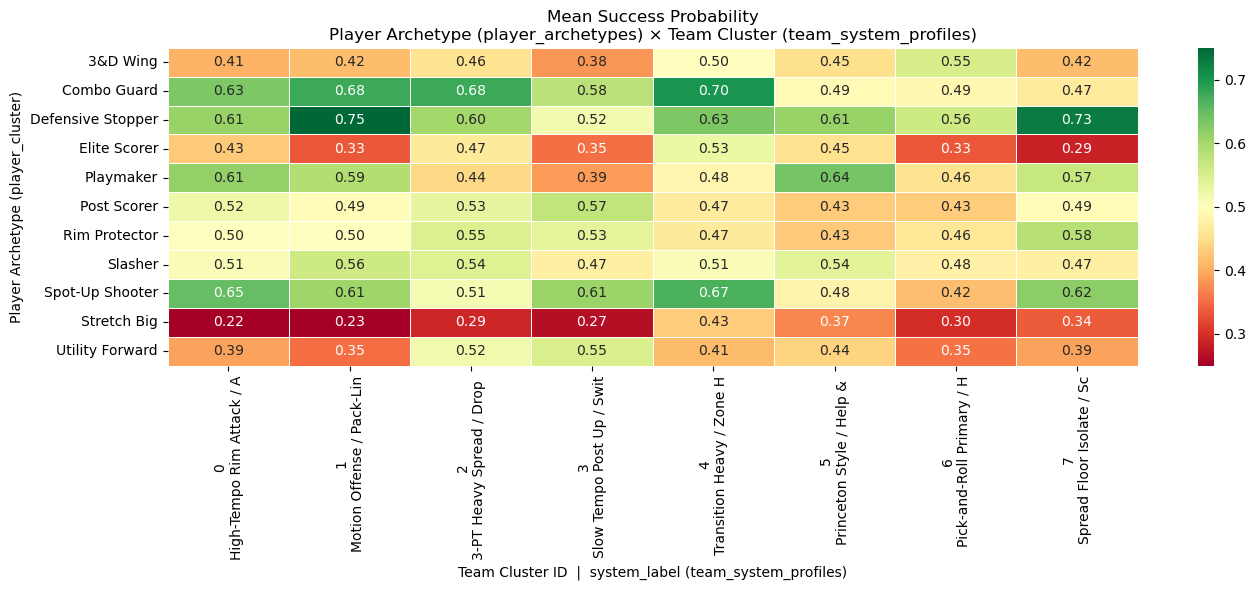

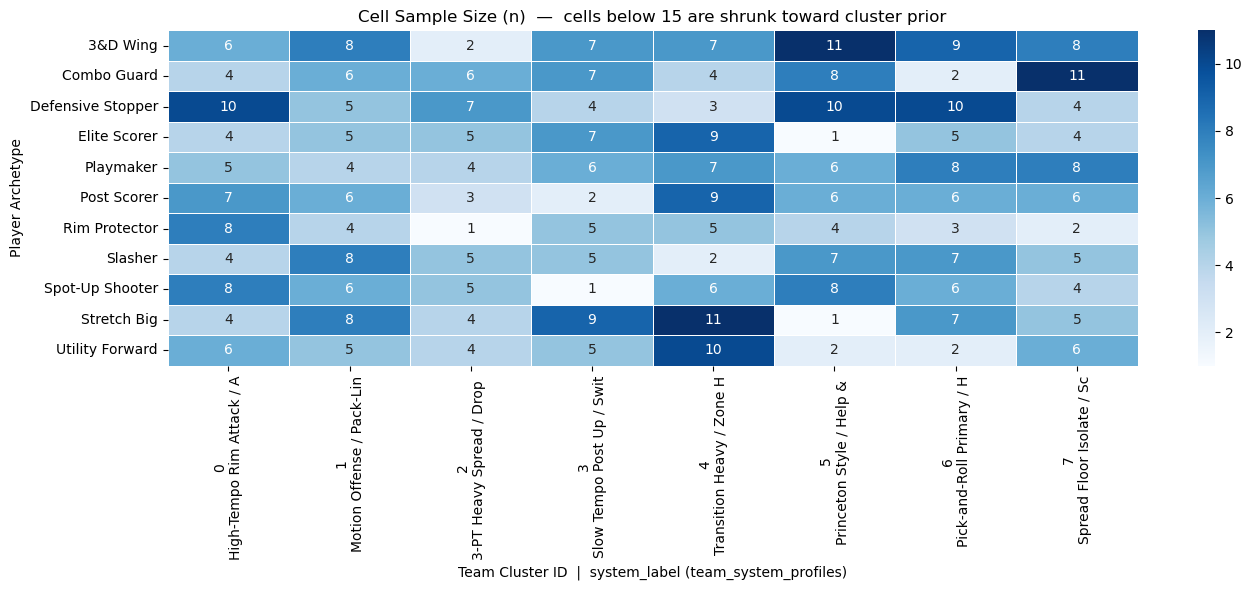

In [82]:
# Cell 7 — Probability heatmap: player_cluster × team_cluster_id (both DB-native)
valid = df[df["team_cluster_id"].notna() & df["player_cluster"].notna()].copy()
valid["team_cluster_id"] = valid["team_cluster_id"].astype(int)
valid["player_cluster"]  = valid["player_cluster"].astype(int)

# Pivot: rows = player archetype, columns = team cluster ID
# Annotate columns with system_label for readability
label_map = (
    valid.dropna(subset=["team_cluster_label"])
    .drop_duplicates("team_cluster_id")
    .set_index("team_cluster_id")["team_cluster_label"]
    .to_dict()
)

heatmap_data = (
    valid.groupby(["player_cluster_label", "team_cluster_id"])["success_probability"]
    .mean()
    .unstack("team_cluster_id")
)
heatmap_data.columns = [
    f"{c}\n{label_map.get(c, '')[:25]}" for c in heatmap_data.columns
]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=0.25, vmax=0.75,
    linewidths=0.5,
    ax=ax,
)
ax.set_title(
    "Mean Success Probability\nPlayer Archetype (player_archetypes) × Team Cluster (team_system_profiles)",
    fontsize=12,
)
ax.set_ylabel("Player Archetype (player_cluster)")
ax.set_xlabel("Team Cluster ID  |  system_label (team_system_profiles)")
plt.tight_layout()
plt.show()

# Also show raw cell counts to visualize where n < 15 (shrinkage active)
cell_counts = (
    valid.groupby(["player_cluster_label", "team_cluster_id"])
    .size()
    .unstack("team_cluster_id", fill_value=0)
)
cell_counts.columns = [
    f"{c}\n{label_map.get(c, '')[:25]}" for c in cell_counts.columns
]

fig2, ax2 = plt.subplots(figsize=(14, 6))
sns.heatmap(
    cell_counts,
    annot=True, fmt="d",
    cmap="Blues",
    linewidths=0.5,
    ax=ax2,
)
ax2.set_title(
    f"Cell Sample Size (n)  —  cells below {CELL_MIN_N} are shrunk toward cluster prior",
    fontsize=12,
)
ax2.set_ylabel("Player Archetype")
ax2.set_xlabel("Team Cluster ID  |  system_label (team_system_profiles)")
plt.tight_layout()
plt.show()

## 5. Risk Explanation Mapping

Translates statistical signals into human-readable UI strings. Rules are evaluated **in priority order**; first match wins.

| Priority | Condition | Risk Flag | UI Text focus |
|---|---|---|---|
| 1 | `minutes_drift < −5` | High Risk (Volume) | Playing-time loss / DNP risk |
| 2 | `−5 ≤ minutes_drift < −2` | Moderate Risk (Volume) | Role compression, monitor rotation |
| 3 | `usage_drift < −4` | High Risk (Usage) | Production at risk in reduced-creation role |
| 4 | `usage_drift > +4` | Opportunity (Usage) | Upside if efficiency holds, downside if TO rate climbs |
| 5 | `success_probability ≥ 0.80` | Low Risk (High Confidence) | Excellent historical precedent in this archetype × program style |
| 6 | `success_probability ≥ 0.65 and minutes_drift ≥ −1` | Low Risk (Stability) | Stable role, strong cohort |
| 7 | `cell_n < 5` | Uncertain (Thin Sample) | Confidence is shrunk heavily — treat with caution |
| default | — | Neutral | No significant risk signals |

In [83]:
# Cell 8 — Risk explanation rules + mapping function

# Each rule: (condition_fn, risk_flag, explanation_template_fn)
# condition_fn: pd.Series row → bool
# explanation_template_fn: pd.Series row → str  (allows injecting team_cluster_label)
RISK_RULES: list[tuple] = [
    (
        lambda r: r.get("minutes_drift", 0) < -5,
        "High Risk (Volume)",
        lambda r: (
            f"Significant playing-time reduction projected at {r.get('team_cluster_label', 'destination')}. "
            "Historical cohort shows elevated DNP/backup risk for this archetype "
            "when minutes fall this sharply at the destination program."
        ),
    ),
    (
        lambda r: -5 <= r.get("minutes_drift", 0) < -2,
        "Moderate Risk (Volume)",
        lambda r: (
            "Modest role compression expected versus projection. "
            f"Monitor early-season rotation fit at {r.get('team_cluster_label', 'destination')} "
            "before adjusting depth-chart projections."
        ),
    ),
    (
        lambda r: r.get("usage_drift", 0) < -4,
        "High Risk (Usage)",
        lambda r: (
            "Usage rate projected to fall sharply — player enters a reduced shot-creation role. "
            "Historical comps show efficiency often drops when creation responsibilities "
            "decrease significantly within this program style."
        ),
    ),
    (
        lambda r: r.get("usage_drift", 0) > 4,
        "Opportunity (Usage)",
        lambda r: (
            "Usage expansion expected. Player enters a higher-creation role with upside "
            "if efficiency holds, but turnover rate can climb when role exceeds prior usage level."
        ),
    ),
    (
        lambda r: r.get("success_probability", 0) >= 0.80,
        "Low Risk (High Confidence)",
        lambda r: (
            f"Excellent historical precedent for this player archetype within "
            f"{r.get('team_cluster_label', 'this program style')}. "
            f"Large cohort sample (n={r.get('cell_n', '?')}) with consistently strong transfer outcomes."
        ),
    ),
    (
        lambda r: r.get("success_probability", 0) >= 0.65 and r.get("minutes_drift", 0) >= -1,
        "Low Risk (Stability)",
        lambda r: (
            "Strong historical cohort success rate with stable role projection. "
            f"Established fit between this player archetype and {r.get('team_cluster_label', 'this program style')}."
        ),
    ),
    (
        lambda r: r.get("cell_n", 0) < 5,
        "Uncertain (Thin Sample)",
        lambda r: (
            f"Very few historical transfers (n={r.get('cell_n', 0)}) for this archetype × "
            f"{r.get('team_cluster_label', 'program style')} combination. "
            "Confidence is shrunk heavily toward the cluster prior — treat as a rough estimate."
        ),
    ),
]

NEUTRAL_EXPLANATION = "No significant risk signals detected. Transfer fits within expected parameters."


def map_risk_explanation(row: pd.Series) -> tuple[str, str]:
    """Return (risk_flag, explanation) for a single transfer row.

    Evaluates RISK_RULES in priority order; returns on first match.
    Explanation strings embed team_cluster_label and cell_n for UI context.
    """
    for condition_fn, flag, explanation_fn in RISK_RULES:
        try:
            if condition_fn(row):
                return flag, explanation_fn(row)
        except (KeyError, TypeError):
            continue
    return "Neutral", NEUTRAL_EXPLANATION


risk_results      = df.apply(map_risk_explanation, axis=1)
df["risk_flag"]   = [r[0] for r in risk_results]
df["explanation"] = [r[1] for r in risk_results]

print("Risk flag distribution:")
display(df["risk_flag"].value_counts())

Risk flag distribution:


Neutral                    180
Moderate Risk (Volume)     107
High Risk (Volume)          72
Opportunity (Usage)         53
High Risk (Usage)           44
Uncertain (Thin Sample)     32
Low Risk (Stability)        12
Name: risk_flag, dtype: int64

## 6. Full Pipeline + Output

The cells above define each step for exploration. This cell wraps them into `run_transfer_success_pipeline()` — a single callable that can be invoked from scripts or other notebooks.

Note: the function only needs `df_transfers` (the SQL output), not a separate team stats frame — program cluster information is already present in the SQL result via the `team_system_profiles` JOIN.

Output columns relevant to the UI:

| Column | Description |
|---|---|
| `success_label` | Bool — met or exceeded the destination projection |
| `value_vs_projection` | Signed delta: actual minus projected `value_per_100` |
| `minutes_drift` | Actual minutes minus projected minutes |
| `usage_drift` | Actual usage rate minus projected usage rate |
| `team_cluster_id` | `team_system_profiles.cluster_id` for the destination school |
| `team_cluster_label` | `team_system_profiles.system_label` for the destination school |
| `success_probability` | Shrinkage-smoothed historical success probability (0–1) |
| `success_tier` | Bucketed label: Very Low → Very High |
| `risk_flag` | Dominant risk category for UI display |
| `explanation` | Human-readable string for the UI tooltip (embeds team cluster label + cell_n) |

In [84]:
# Cell 9 — Pipeline wrapper

def run_transfer_success_pipeline(
    df_transfers: pd.DataFrame,
    shrinkage_k: int = SHRINKAGE_K,
) -> pd.DataFrame:
    """End-to-end Transfer Success & Confidence pipeline.

    Args:
        df_transfers: Output of TRANSFER_SQL (one completed transfer per row).
                      Must contain team_cluster_id and team_cluster_label from
                      the team_system_profiles JOIN — no separate team frame needed.
        shrinkage_k:  Bayesian shrinkage constant K (default 10).

    Returns:
        Annotated transfer DataFrame with success_label, drift metrics,
        success_probability, and risk_flag / explanation columns.
    """
    # Step 1: success labels + volume/efficiency drift
    out = label_transfer_success(df_transfers)
    out = compute_drift(out)

    # Step 2: empirical Bayes success probability — player_cluster × team_cluster_id (DB-native)
    out = compute_success_probabilitys(out, shrinkage_k=shrinkage_k)

    # Step 3: risk explanation mapping
    risk_results        = out.apply(map_risk_explanation, axis=1)
    out["risk_flag"]    = [r[0] for r in risk_results]
    out["explanation"]  = [r[1] for r in risk_results]

    return out


# Re-run end-to-end to confirm pipeline is self-contained
result_df = run_transfer_success_pipeline(df_transfers)

OUTPUT_COLS = [
    "player_id", "player_name", "season",
    "player_cluster_label",
    "team_cluster_id", "team_cluster_label",
    "projected_value_per_100", "actual_value_per_100",
    "success_label", "value_vs_projection",
    "minutes_drift", "usage_drift",
    "cell_n", "shrinkage_w", "success_probability", "success_tier",
    "risk_flag",
]
print(f"Pipeline output: {len(result_df):,} rows × {len(result_df.columns)} columns")
display(result_df[OUTPUT_COLS].head(20))

Pipeline output: 500 rows × 41 columns


,player_id,player_name,season,player_cluster_label,team_cluster_id,team_cluster_label,projected_value_per_100,actual_value_per_100,success_label,value_vs_projection,minutes_drift,usage_drift,cell_n,shrinkage_w,success_probability,success_tier,risk_flag
0,7568,Player_0,2025,Elite Scorer,0,High-Tempo Rim Attack / Aggressive Press,-0.289,-0.377,False,-0.089,-5.560,4.654,4,0.286,0.429,Low,High Risk (Volume)
1,6351,Player_1,2024,Defensive Stopper,5,Princeton Style / Help & Recover,3.384,5.965,True,2.581,4.177,-1.225,10,0.500,0.611,Moderate,Neutral
2,5119,Player_2,2024,Post Scorer,7,Spread Floor Isolate / Scramble Defense,-6.842,-6.020,True,0.822,5.931,4.418,6,0.375,0.493,Low,Opportunity (Usage)
3,4925,Player_3,2025,Stretch Big,6,Pick-and-Roll Primary / Hedge & Recover,-4.490,-2.925,True,1.565,1.054,1.716,7,0.412,0.298,Very Low,Neutral
4,4653,Player_4,2022,Stretch Big,2,3-PT Heavy Spread / Drop Coverage,-2.769,-4.570,False,-1.802,-0.881,-1.371,4,0.286,0.290,Very Low,Uncertain (Thin Sample)
5,6210,Player_5,2025,Utility Forward,3,Slow Tempo Post Up / Switching Man,4.384,5.431,True,1.048,2.002,1.919,5,0.333,0.550,Moderate,Neutral
6,2608,Player_6,2025,Elite Scorer,4,Transition Heavy / Zone Heavy,0.848,2.305,True,1.457,-14.308,1.282,9,0.474,0.526,Moderate,High Risk (Volume)
7,5657,Player_7,2024,Post Scorer,1,Motion Offense / Pack-Line Man Defense,2.302,1.149,False,-1.153,1.511,4.084,6,0.375,0.493,Low,Opportunity (Usage)
8,2852,Player_8,2024,Rim Protector,2,3-PT Heavy Spread / Drop Coverage,-3.420,-2.301,True,1.119,-0.567,-2.193,1,0.091,0.545,Moderate,Uncertain (Thin Sample)
9,7128,Player_9,2024,3&D Wing,1,Motion Offense / Pack-Line Man Defense,-3.359,-2.226,True,1.132,-0.253,0.165,8,0.444,0.416,Low,Neutral


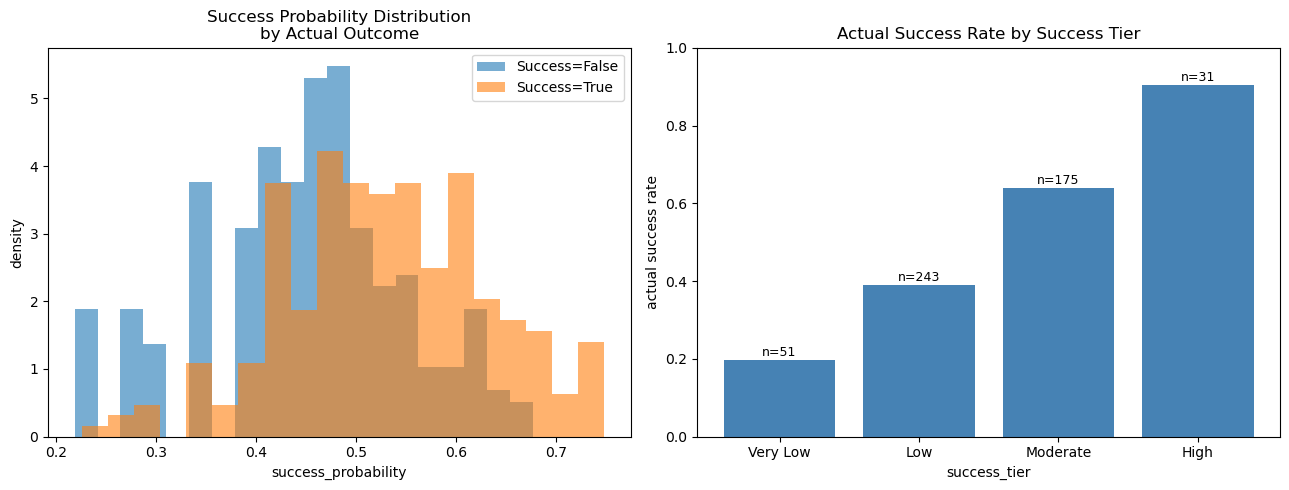


Calibration check (success tier vs actual success rate):


,success_tier,actual_success_rate,n
0,Very Low,0.196,51
1,Low,0.391,243
2,Moderate,0.640,175
3,High,0.903,31


In [85]:
# Cell 10 — Calibration: Success tier vs actual success rate
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labeled_mask = result_df["success"].notna()
for label, grp in result_df[labeled_mask].groupby("success_label"):
    axes[0].hist(
        grp["success_probability"], bins=20, alpha=0.6,
        label=f"Success={label}", density=True,
    )
axes[0].set_title("Success Probability Distribution\nby Actual Outcome")
axes[0].set_xlabel("success_probability")
axes[0].set_ylabel("density")
axes[0].legend()

tier_actual = (
    result_df[labeled_mask]
    .groupby("success_tier", observed=True)["success"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "actual_success_rate", "count": "n"})
    .reset_index()
)
axes[1].bar(
    tier_actual["success_tier"].astype(str),
    tier_actual["actual_success_rate"],
    color="steelblue",
)
for idx, row in tier_actual.iterrows():
    axes[1].text(idx, row["actual_success_rate"] + 0.01, f"n={row['n']}", ha="center", fontsize=9)
axes[1].set_title("Actual Success Rate by Success Tier")
axes[1].set_xlabel("success_tier")
axes[1].set_ylabel("actual success rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nCalibration check (success tier vs actual success rate):")
display(tier_actual.round(3))

In [86]:
# Cell 11 — Risk flag breakdown + sample explanation strings for UI review
print("Risk flag distribution by transfer type:")
display(
    result_df.groupby(["risk_flag", "transfer_type"])
    .size()
    .unstack(fill_value=0)
)

print("\n--- Sample UI explanation strings per risk flag ---")
for flag, grp in result_df.groupby("risk_flag"):
    sample = grp.iloc[0]
    print(f"\n[{flag}]")
    print(f"  Player:           {sample['player_name']} | Season: {sample['season']}")
    print(f"  Team cluster:     {sample['team_cluster_label']} (id={sample['team_cluster_id']})")
    print(f"  Player archetype: {sample['player_cluster_label']}")
    print(f"  minutes_drift={sample['minutes_drift']:.1f}  usage_drift={sample['usage_drift']:.1f}")
    print(f"  success_probability={sample['success_probability']:.2f}  cell_n={sample['cell_n']}  W={sample['shrinkage_w']:.2f}")
    print(f"  UI text: {sample['explanation']}")

Risk flag distribution by transfer type:


transfer_type,graduate,regular
risk_flag,,
High Risk (Usage),17,27
High Risk (Volume),29,43
Low Risk (Stability),6,6
Moderate Risk (Volume),54,53
Neutral,79,101
Opportunity (Usage),24,29
Uncertain (Thin Sample),11,21



--- Sample UI explanation strings per risk flag ---

[High Risk (Usage)]
  Player:           Player_15 | Season: 2025
  Team cluster:     High-Tempo Rim Attack / Aggressive Press (id=0)
  Player archetype: Defensive Stopper
  minutes_drift=0.6  usage_drift=-5.3
  success_probability=0.61  cell_n=10  W=0.50
  UI text: Usage rate projected to fall sharply — player enters a reduced shot-creation role. Historical comps show efficiency often drops when creation responsibilities decrease significantly within this program style.

[High Risk (Volume)]
  Player:           Player_0 | Season: 2025
  Team cluster:     High-Tempo Rim Attack / Aggressive Press (id=0)
  Player archetype: Elite Scorer
  minutes_drift=-5.6  usage_drift=4.7
  success_probability=0.43  cell_n=4  W=0.29
  UI text: Significant playing-time reduction projected at High-Tempo Rim Attack / Aggressive Press. Historical cohort shows elevated DNP/backup risk for this archetype when minutes fall this sharply at the destination pr

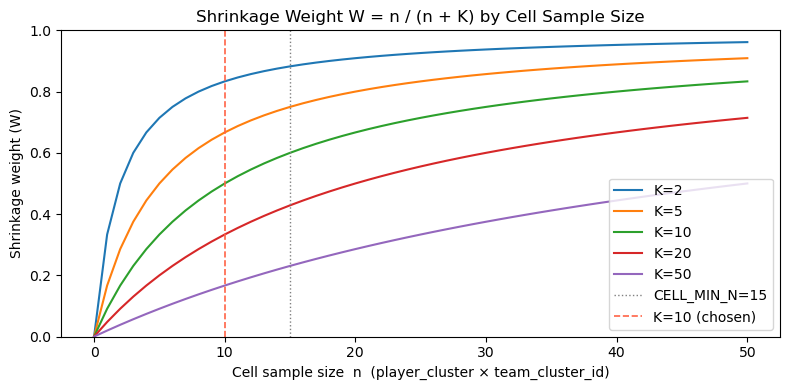

At K=10:
  n= 5 → W=0.33  (cell contributes 33%, cluster prior contributes 67%)
  n=10 → W=0.50  (cell contributes 50%, cluster prior contributes 50%)
  n=15 → W=0.60  (cell contributes 60%, cluster prior contributes 40%)
  n=25 → W=0.71  (cell contributes 71%, cluster prior contributes 29%)
  n=50 → W=0.83  (cell contributes 83%, cluster prior contributes 17%)


In [87]:
# Cell 12 — Shrinkage sensitivity: W = n / (n + K) for different K values
K_values    = [2, 5, 10, 20, 50]
n_obs_range = np.arange(0, 51)

fig, ax = plt.subplots(figsize=(8, 4))
for K in K_values:
    W = n_obs_range / (n_obs_range + K)
    ax.plot(n_obs_range, W, label=f"K={K}")

ax.axvline(CELL_MIN_N, color="gray", linestyle=":", linewidth=1,
           label=f"CELL_MIN_N={CELL_MIN_N}")
ax.axvline(SHRINKAGE_K, color="tomato", linestyle="--", linewidth=1.2,
           label=f"K={SHRINKAGE_K} (chosen)")
ax.set_title("Shrinkage Weight W = n / (n + K) by Cell Sample Size")
ax.set_xlabel("Cell sample size  n  (player_cluster × team_cluster_id)")
ax.set_ylabel("Shrinkage weight (W)")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"At K={SHRINKAGE_K}:")
for n in [5, 10, 15, 25, 50]:
    W = n / (n + SHRINKAGE_K)
    print(f"  n={n:2d} → W={W:.2f}  (cell contributes {W:.0%}, cluster prior contributes {1-W:.0%})")

## 7. Validation & Evaluation

Three-part statistical evaluation of the pipeline's reliability:

| Section | What it measures |
|---|---|
| **7a. Success Probability Calibration** | Does `success_probability` actually predict success? Brier Score Loss + density split + tier success rates |
| **7b. Risk Flag Accuracy & Precision** | Do risk flags correctly identify failing transfers? Precision / Recall / F1 treating High/Moderate Risk flags as failure predictors |
| **7c. Opportunity (Usage) Variance Check** | Does the Opportunity flag isolate high-variance boom-or-bust transfers? Std comparison vs Neutral group |

In [88]:
# Cell 13a — Validation setup: shared eval DataFrame
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

TIER_ORDER = ["Very Low", "Low", "Moderate", "High", "Very High"]

# Restrict to rows with a definitive labeled outcome
eval_df = result_df[result_df["success_label"].notna()].copy()
eval_df["success_int"] = eval_df["success_label"].astype(int)
eval_df["failed"]      = ~eval_df["success_label"].astype(bool)

print(f"Evaluation set: {len(eval_df):,} labeled transfers")
print(f"  Success: {eval_df['success_int'].sum():,}  |  Failure: {eval_df['failed'].sum():,}")
print(f"  Base rate: {eval_df['success_int'].mean():.1%} success  /  {eval_df['failed'].mean():.1%} failure")

Evaluation set: 500 labeled transfers
  Success: 245  |  Failure: 255
  Base rate: 49.0% success  /  51.0% failure


In [89]:
# Cell 13b — 7a: Confidence calibration metrics (Brier Score + calibration curve)

# Empirical success rate and sample count per confidence tier
tier_stats = (
    eval_df
    .groupby("success_tier", observed=False)
    .agg(n=("success_int", "count"), actual_success_rate=("success_int", "mean"))
    .reindex(TIER_ORDER)
    .reset_index()
)

# Brier Score: mean squared error of predicted probability vs binary outcome
# Lower is better; 0.25 = coin-flip baseline at a 50/50 base rate
y_true = eval_df["success_int"]
y_prob  = eval_df["success_probability"]
brier   = brier_score_loss(y_true, y_prob)

# Calibration curve: fraction of positives vs mean predicted prob in quantile bins
frac_pos, mean_pred_prob = calibration_curve(y_true, y_prob, n_bins=5, strategy="quantile")

brier_interp = (
    "Excellent (<0.15)" if brier < 0.15
    else "Good (0.15–0.20)" if brier < 0.20
    else "Fair (0.20–0.25)" if brier < 0.25
    else "Weak — near coin-flip (≥0.25)"
)

print(f"Brier Score Loss : {brier:.4f}   [{brier_interp}]")
print(f"Reference baseline : 0.25  (uninformative at 50/50 base rate)")

Brier Score Loss : 0.2209   [Fair (0.20–0.25)]
Reference baseline : 0.25  (uninformative at 50/50 base rate)


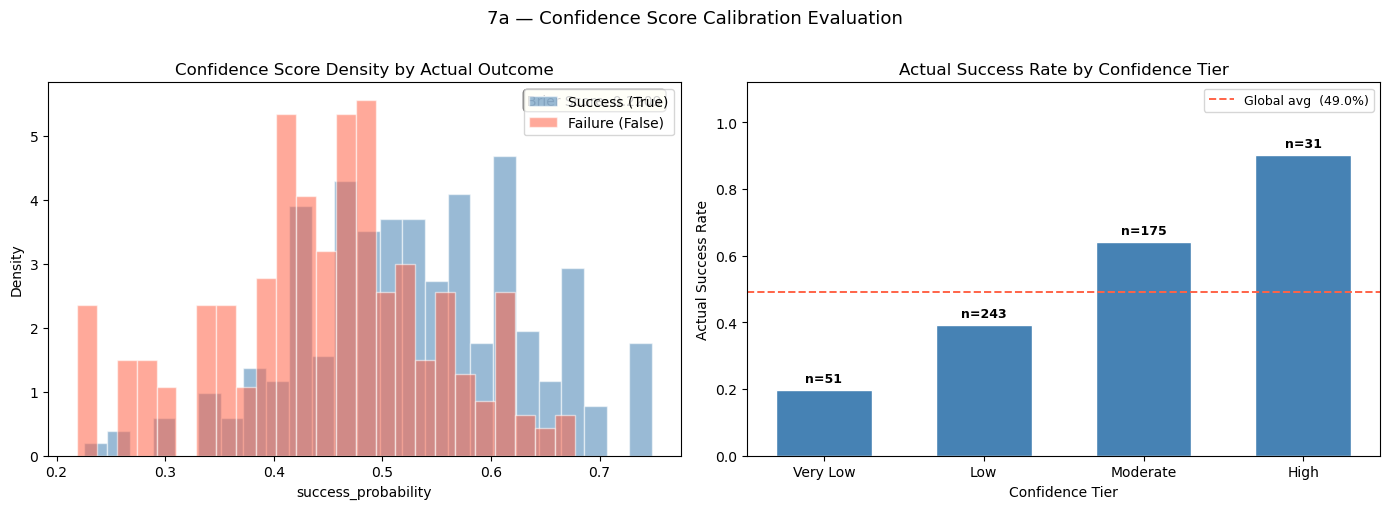

In [90]:
# Cell 13c — 7a: Calibration visualization (2-panel plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: confidence score density split by actual outcome
for outcome, color, label in [
    (True,  "steelblue", "Success (True)"),
    (False, "tomato",    "Failure (False)"),
]:
    subset = eval_df.loc[eval_df["success_label"] == outcome, "success_probability"]
    axes[0].hist(subset, bins=25, alpha=0.55, density=True, color=color,
                 label=label, edgecolor="white")

axes[0].set_title("Confidence Score Density by Actual Outcome", fontsize=12)
axes[0].set_xlabel("success_probability")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].text(
    0.97, 0.97,
    f"Brier Score: {brier:.4f}",
    transform=axes[0].transAxes, ha="right", va="top", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"),
)

# Right panel: actual success rate per confidence tier with "n=X" labels
valid_tiers = tier_stats[tier_stats["n"] > 0]
global_rate = eval_df["success_int"].mean()

bars = axes[1].bar(
    valid_tiers["success_tier"].astype(str),
    valid_tiers["actual_success_rate"],
    color="steelblue", edgecolor="white", width=0.6,
)
for bar, (_, row) in zip(bars, valid_tiers.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"n={int(row['n'])}",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
    )

axes[1].axhline(global_rate, color="tomato", linestyle="--", linewidth=1.4,
                label=f"Global avg  ({global_rate:.1%})")
axes[1].set_title("Actual Success Rate by Confidence Tier", fontsize=12)
axes[1].set_xlabel("Confidence Tier")
axes[1].set_ylabel("Actual Success Rate")
axes[1].set_ylim(0, 1.12)
axes[1].legend(fontsize=9)

plt.suptitle("7a — Confidence Score Calibration Evaluation", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [91]:
# Cell 13d — 7a: Calibration printout + tier summary table
print(f"\n{'─'*62}")
print(f"  Brier Score Loss    : {brier:.4f}   [{brier_interp}]")
print(f"  Reference baseline  : 0.25  (uninformative at 50/50 base rate)")
print(f"  Global success rate : {global_rate:.1%}  (n={len(eval_df):,} labeled transfers)")
print(f"\n  Calibration curve — quantile bins (mean predicted → fraction positive):")
for mp, fp in zip(mean_pred_prob, frac_pos):
    gap = fp - mp
    direction = "over-confident" if gap < 0 else "under-confident"
    print(f"    predicted {mp:.3f}  →  actual {fp:.3f}   (gap {gap:+.3f}  {direction})")
print(f"{'─'*62}\n")

print("Tier Calibration Summary:")
display(
    tier_stats
    .assign(actual_success_rate=tier_stats["actual_success_rate"].map(
        lambda x: f"{x:.1%}" if pd.notna(x) else "—"
    ))
    .rename(columns={
        "success_tier":    "Confidence Tier",
        "n":                  "Count",
        "actual_success_rate":"Actual Success Rate",
    })
    .reset_index(drop=True)
)


──────────────────────────────────────────────────────────────
  Brier Score Loss    : 0.2209   [Fair (0.20–0.25)]
  Reference baseline  : 0.25  (uninformative at 50/50 base rate)
  Global success rate : 49.0%  (n=500 labeled transfers)

  Calibration curve — quantile bins (mean predicted → fraction positive):
    predicted 0.337  →  actual 0.252   (gap -0.084  over-confident)
    predicted 0.438  →  actual 0.404   (gap -0.034  over-confident)
    predicted 0.485  →  actual 0.434   (gap -0.051  over-confident)
    predicted 0.545  →  actual 0.614   (gap +0.069  under-confident)
    predicted 0.643  →  actual 0.758   (gap +0.115  under-confident)
──────────────────────────────────────────────────────────────

Tier Calibration Summary:


,Confidence Tier,Count,Actual Success Rate
0,Very Low,51,19.6%
1,Low,243,39.1%
2,Moderate,175,64.0%
3,High,31,90.3%
4,Very High,0,—


In [92]:
# Cell 13e — 7b: Risk flag stats + confusion matrix computation

# Per risk-flag aggregate: sample count, failure rate, success rate
flag_stats = (
    eval_df
    .groupby("risk_flag", sort=False)
    .agg(
        total_cases=("failed", "count"),
        actual_failure_rate=("failed", "mean"),
        actual_success_rate=("success_int", "mean"),
    )
    .reset_index()
    .sort_values("actual_failure_rate", ascending=False)
)

# Flags whose purpose is to predict failure (positive class = "transfer fails")
FAILURE_FLAGS = {
    "High Risk (Volume)",
    "High Risk (Usage)",
    "Moderate Risk (Volume)",
    "Uncertain (Thin Sample)",
}

# Per-flag precision: when a risk flag fires, how often was it right about failure?
flag_stats["precision_for_failure"] = np.where(
    flag_stats["risk_flag"].isin(FAILURE_FLAGS),
    flag_stats["actual_failure_rate"],
    np.nan,
)

# Confusion matrix components across all FAILURE_FLAGS combined
flagged     = eval_df[eval_df["risk_flag"].isin(FAILURE_FLAGS)]
not_flagged = eval_df[~eval_df["risk_flag"].isin(FAILURE_FLAGS)]

tp = int(flagged["failed"].sum())          # flagged AND actually failed
fp = int(flagged["success_int"].sum())     # flagged BUT actually succeeded (misfire)
fn = int(not_flagged["failed"].sum())      # not flagged BUT actually failed (missed)
tn = int(not_flagged["success_int"].sum()) # not flagged AND actually succeeded

precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall      = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"Failure-predictor flags: {sorted(FAILURE_FLAGS)}")
print(f"  Total flagged: {len(flagged):,}  |  Total not flagged: {len(not_flagged):,}")
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

Failure-predictor flags: ['High Risk (Usage)', 'High Risk (Volume)', 'Moderate Risk (Volume)', 'Uncertain (Thin Sample)']
  Total flagged: 255  |  Total not flagged: 245
  TP=136  FP=119  FN=119  TN=126


In [93]:
# Cell 13f — 7b: Risk flag display table + precision/recall printout
flag_display = (
    flag_stats
    .assign(
        actual_failure_rate=flag_stats["actual_failure_rate"].map("{:.1%}".format),
        actual_success_rate=flag_stats["actual_success_rate"].map("{:.1%}".format),
        precision_for_failure=flag_stats["precision_for_failure"].map(
            lambda x: f"{x:.1%}" if pd.notna(x) else "—"
        ),
    )
    .rename(columns={
        "risk_flag":             "Risk Flag",
        "total_cases":           "Total Cases",
        "actual_failure_rate":   "Actual Failure Rate",
        "actual_success_rate":   "Actual Success Rate",
        "precision_for_failure": "Precision (Failure)",
    })
    .reset_index(drop=True)
)

print("\n7b — Risk Flag Accuracy & Precision Profile")
print("=" * 65)
display(flag_display)

print(f"\n{'─'*65}")
print(f"  Failure-predictor flags : {sorted(FAILURE_FLAGS)}")
print(f"{'─'*65}")
print(f"  TP  (flagged  + failed)     : {tp:>4,}   correctly warned")
print(f"  FP  (flagged  + succeeded)  : {fp:>4,}   flag misfired")
print(f"  FN  (missed   + failed)     : {fn:>4,}   undetected failure")
print(f"  TN  (not flag + succeeded)  : {tn:>4,}   correctly not flagged")
print(f"{'─'*65}")
print(f"  Precision   : {precision:.3f}   of flagged transfers, {precision:.1%} actually failed")
print(f"  Recall      : {recall:.3f}   pipeline caught {recall:.1%} of all actual failures")
print(f"  F1-Score    : {f1:.3f}")
print(f"  Specificity : {specificity:.3f}   avoided flagging {specificity:.1%} of actual successes")
print(f"{'─'*65}\n")


7b — Risk Flag Accuracy & Precision Profile


,Risk Flag,Total Cases,Actual Failure Rate,Actual Success Rate,Precision (Failure)
0,Uncertain (Thin Sample),32,68.8%,31.2%,68.8%
1,High Risk (Volume),72,52.8%,47.2%,52.8%
2,Opportunity (Usage),53,50.9%,49.1%,—
3,Moderate Risk (Volume),107,50.5%,49.5%,50.5%
4,High Risk (Usage),44,50.0%,50.0%,50.0%
5,Neutral,180,49.4%,50.6%,—
6,Low Risk (Stability),12,25.0%,75.0%,—



─────────────────────────────────────────────────────────────────
  Failure-predictor flags : ['High Risk (Usage)', 'High Risk (Volume)', 'Moderate Risk (Volume)', 'Uncertain (Thin Sample)']
─────────────────────────────────────────────────────────────────
  TP  (flagged  + failed)     :  136   correctly warned
  FP  (flagged  + succeeded)  :  119   flag misfired
  FN  (missed   + failed)     :  119   undetected failure
  TN  (not flag + succeeded)  :  126   correctly not flagged
─────────────────────────────────────────────────────────────────
  Precision   : 0.533   of flagged transfers, 53.3% actually failed
  Recall      : 0.533   pipeline caught 53.3% of all actual failures
  F1-Score    : 0.533
  Specificity : 0.514   avoided flagging 51.4% of actual successes
─────────────────────────────────────────────────────────────────



In [94]:
# Cell 13g — 7c: Opportunity (Usage) variance check vs Neutral
COMPARE_FLAGS = ["Opportunity (Usage)", "Neutral"]

variance_check = (
    result_df[result_df["risk_flag"].isin(COMPARE_FLAGS)]
    .groupby("risk_flag")["value_vs_projection"]
    .agg(count="count", mean="mean", std="std", min="min", max="max")
    .loc[COMPARE_FLAGS]  # enforce display order
    .round(3)
)

print("\n7c — Opportunity (Usage) vs Neutral: value_vs_projection distribution")
print("=" * 65)
print(variance_check.to_string())

opp_std     = variance_check.loc["Opportunity (Usage)", "std"]
neutral_std = variance_check.loc["Neutral", "std"]
is_wider    = opp_std > neutral_std

print(f"\n{'─'*65}")
print(f"  Opportunity (Usage) std : {opp_std:.3f}")
print(f"  Neutral std             : {neutral_std:.3f}")
print(f"  Std ratio               : {opp_std / neutral_std:.2f}x")
print(f"{'─'*65}")
if is_wider:
    print(
        f"  CONFIRMED: 'Opportunity (Usage)' has higher variance than 'Neutral'\n"
        f"  ({opp_std:.3f} vs {neutral_std:.3f}) — flag successfully isolates\n"
        f"  high-variance, boom-or-bust transfers."
    )
else:
    print(
        f"  NOT CONFIRMED: 'Opportunity (Usage)' std ({opp_std:.3f}) is not\n"
        f"  higher than 'Neutral' ({neutral_std:.3f}) — flag may not be\n"
        f"  isolating high-variance transfers as expected."
    )
print(f"{'─'*65}\n")


7c — Opportunity (Usage) vs Neutral: value_vs_projection distribution
                     count   mean   std    min   max
risk_flag                                           
Opportunity (Usage)     53 -0.178 1.972 -4.828 4.774
Neutral                180  0.031 2.010 -4.428 5.421

─────────────────────────────────────────────────────────────────
  Opportunity (Usage) std : 1.972
  Neutral std             : 2.010
  Std ratio               : 0.98x
─────────────────────────────────────────────────────────────────
  NOT CONFIRMED: 'Opportunity (Usage)' std (1.972) is not
  higher than 'Neutral' (2.010) — flag may not be
  isolating high-variance transfers as expected.
─────────────────────────────────────────────────────────────────

